# EDA 2 (Interim) - RECH6: Antropometría y Anemia
Este notebook realiza la auditoría post-limpieza del módulo RECH6 (Target del proyecto).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
import pandas as pd
from mnp.config import INTERIM_DATA_DIR

DATA_PATH = INTERIM_DATA_DIR / "rech6_cleaned.parquet"

print(f"Cargando datos desde: {DATA_PATH}")
df_rech6 = pd.read_parquet(DATA_PATH)

print(f"Filas: {len(df_rech6):,}")
print(f"Columnas: {len(df_rech6.columns)}")
df_rech6.head()


2026-06-14 15:37:05.176 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


Cargando datos desde: /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech6_cleaned.parquet
Filas: 294,109
Columnas: 38


,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,...,HC60,HC61,HC62,HC63,HC64,HC70,HC71,HC72,HC73,year
0,1 10,3,20.0,9.6,76.6,177.0,-2.10,9201.0,830.0,-1.38,...,2,3.0,3.0,NaN,1.0,-2.14,-0.92,0.18,0.57,2007
1,1 22,5,28.0,13.7,83.2,468.0,-1.68,9355.0,6255.0,0.32,...,2,1.0,5.0,101.0,3.0,-2.21,0.48,2.32,2.68,2007
2,1 34,3,40.0,12.8,92.0,956.0,-1.31,9481.0,948.0,-1.31,...,2,3.0,2.0,NaN,1.0,-1.53,-1.08,-0.30,-0.15,2007
3,26 3,4,52.0,17.6,109.0,8757.0,1.15,10461.0,6560.0,0.40,...,3,1.0,3.0,80.0,3.0,0.83,0.29,-0.37,-0.31,2007
4,26 3,5,34.0,13.2,83.4,37.0,-2.68,8935.0,2494.0,-0.68,...,3,1.0,3.0,18.0,4.0,-3.12,-0.48,1.85,2.35,2007


## 1. Auditoría de Variables Clínicas Clave (HC70, HC71, HC72)

In [4]:
cols_clinicas = ['HC70', 'HC71', 'HC72', 'HC73']
df_rech6[cols_clinicas].describe()

,HC70,HC71,HC72,HC73
count,285284.000000,285284.000000,285284.00000,285284.000000
mean,-0.947255,-0.158242,0.53526,0.614699
std,1.079254,1.067975,1.01780,1.001546
min,-6.000000,-5.760000,-4.98000,-4.980000
25%,-1.660000,-0.860000,-0.12000,-0.020000
50%,-0.940000,-0.200000,0.50000,0.580000
75%,-0.230000,0.500000,1.15000,1.220000
max,5.970000,4.980000,5.00000,5.000000


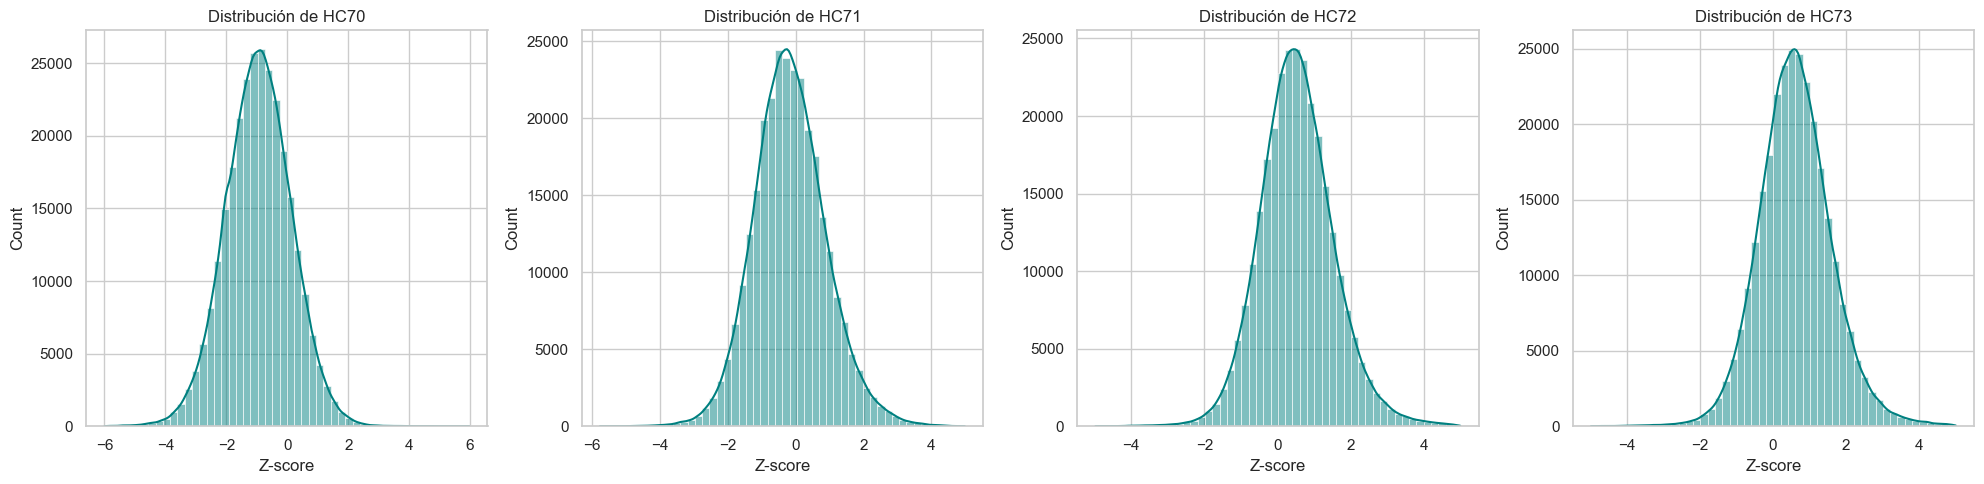

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(cols_clinicas):
    sns.histplot(df_rech6[col].dropna(), bins=50, ax=axes[i], kde=True, color='teal')
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Z-score")
    
plt.tight_layout()
plt.show()

## 2. Evolución Histórica de los Nulos en HC70
¿Mejoró la recolección de antropometría con el tiempo?

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_2045/3413560032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_por_ano.index, y=nulos_por_ano.values, palette="viridis")


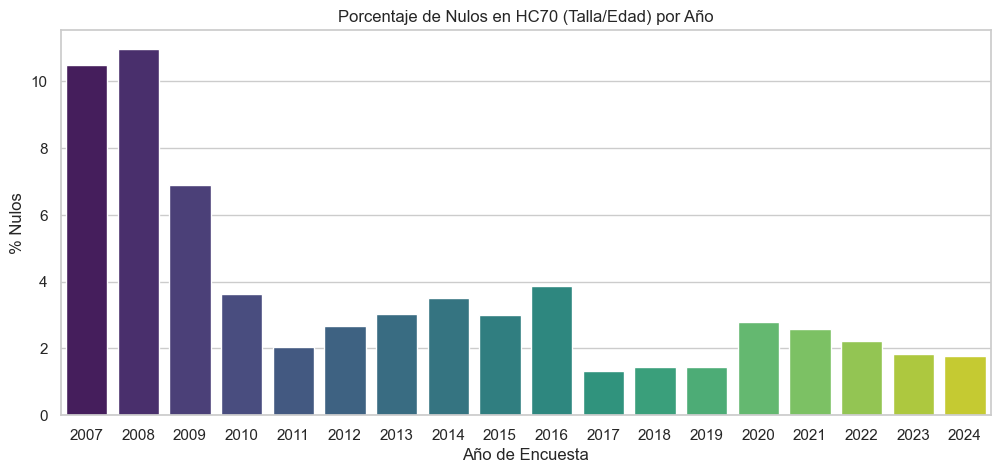

In [6]:
nulos_por_ano = df_rech6.groupby('year')['HC70'].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(12, 5))
sns.barplot(x=nulos_por_ano.index, y=nulos_por_ano.values, palette="viridis")
plt.title("Porcentaje de Nulos en HC70 (Talla/Edad) por Año")
plt.ylabel("% Nulos")
plt.xlabel("Año de Encuesta")
plt.show()

## 3. Prevalencia Real (Desbalance de Clases)
Según la OMS, un niño sufre Desnutrición Crónica (Stunting) si su Z-score de Talla/Edad () es menor a -2.0.

Prevalencia Histórica Total (2007-2024):
stunting_flag
Sano                  83.93
Desnutrido (<-2.0)    16.07
Name: proportion, dtype: float64


/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_2045/1400878152.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech6, x='stunting_flag', palette='Set2')


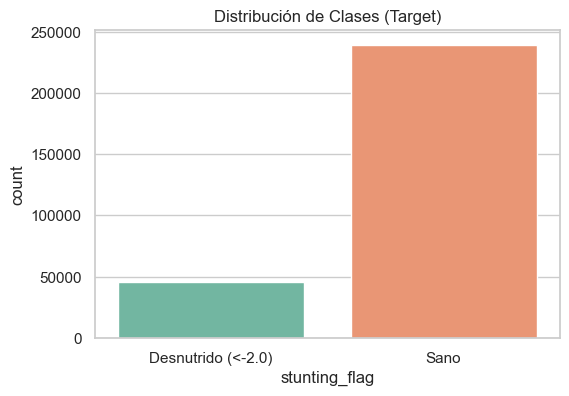

In [7]:
# Crear flag binario de desnutrición crónica
df_rech6['stunting_flag'] = df_rech6['HC70'].apply(lambda x: 'Desnutrido (<-2.0)' if x < -2.0 else ('Sano' if pd.notnull(x) else np.nan))

prevalencia = df_rech6['stunting_flag'].value_counts(normalize=True) * 100
print("Prevalencia Histórica Total (2007-2024):")
print(prevalencia.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_rech6, x='stunting_flag', palette='Set2')
plt.title("Distribución de Clases (Target)")
plt.show()

## 4. Curva de Acumulación por Edad ()

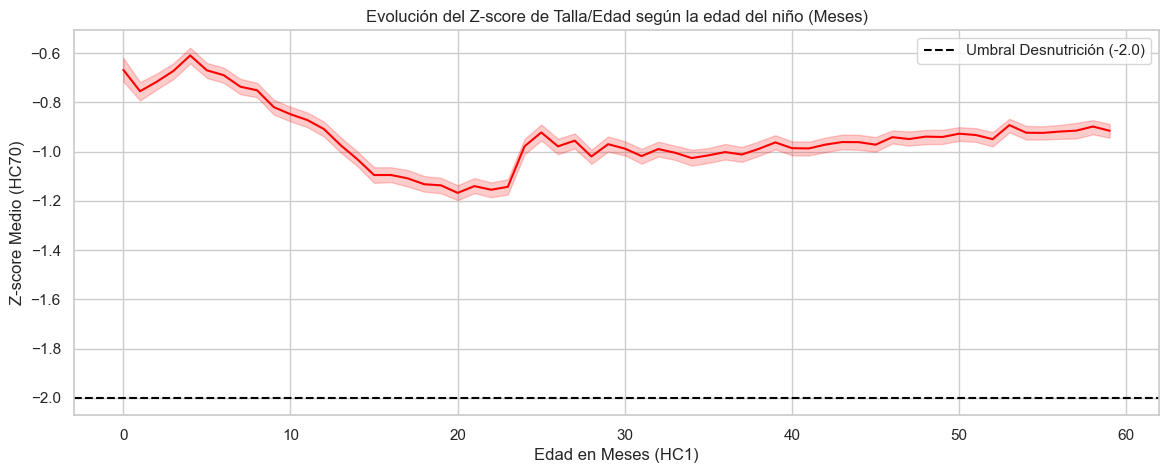

In [8]:
# Promedio de Z-score por Edad en meses (0 a 59 meses)
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_rech6, x='HC1', y='HC70', errorbar='ci', color='red')
plt.axhline(-2.0, ls='--', color='black', label='Umbral Desnutrición (-2.0)')
plt.title("Evolución del Z-score de Talla/Edad según la edad del niño (Meses)")
plt.xlabel("Edad en Meses (HC1)")
plt.ylabel("Z-score Medio (HC70)")
plt.legend()
plt.show()

## 5. Validación del Coalesce de Anemia ()

Distribución de Niveles de Anemia (Coalesce):
HC57
4.0    167181
3.0     61394
NaN     35411
2.0     29442
1.0       681
Name: count, dtype: int64


/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_2045/1608017247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_rech6['HC57'].astype(str), order=df_rech6['HC57'].astype(str).value_counts().index, palette='magma')


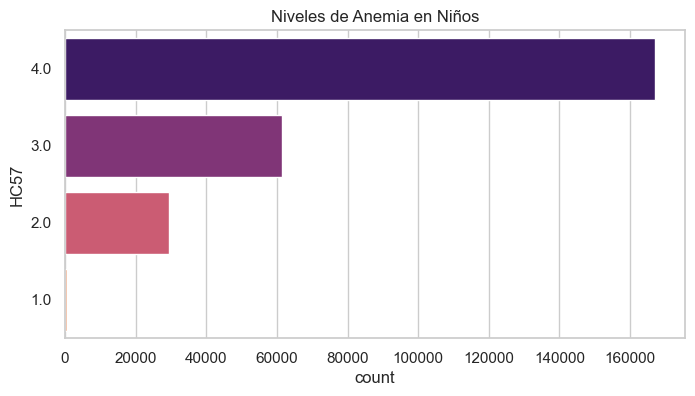

In [9]:
# Validar si el Coalesce funcionó y revisar la distribución
if 'HC57' in df_rech6.columns:
    print("Distribución de Niveles de Anemia (Coalesce):")
    print(df_rech6['HC57'].value_counts(dropna=False))
    
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df_rech6['HC57'].astype(str), order=df_rech6['HC57'].astype(str).value_counts().index, palette='magma')
    plt.title("Niveles de Anemia en Niños")
    plt.show()
else:
    print("La columna HC57 no se encontró en el parquet.")

## 6. Sesgo de Nulos (MNAR) - Razón de No Medición ()

In [10]:
# Filtrar solo a los niños que NO tienen HC70 y ver su razón en HC13
nulos_hc70 = df_rech6[df_rech6['HC70'].isna()]
razon_nulos = nulos_hc70['HC13'].value_counts(dropna=False)
print("Razones por las que el niño NO fue medido (cuando HC70 es nulo):")
print(razon_nulos)

Razones por las que el niño NO fue medido (cuando HC70 es nulo):
HC13
Rechazó                3560
No presente            2867
Otro                   1432
Medido                  876
Parcialmente medido      80
NaN                      10
Name: count, dtype: int64


## 7. Conclusiones y Hallazgos Clínicos del EDA 2

**Resumen de Insights Críticos descubiertos tras la limpieza:**

*   **Prevalencia Real (16.07%)**: La tasa histórica de desnutrición crónica concuerda perfectamente con los promedios nacionales del INEI. Al ser 16% vs 84%, nos enfrentamos a un **Desbalance de Clases**, por lo que los algoritmos predictivos requerirán técnicas de balanceo (SMOTE o *Class Weights*).
*   **Caída Crítica por Edad (0 a 20 meses)**: La curva de Z-score cae en picada desde el nacimiento hasta los 20 meses. Esto refleja el fuerte impacto biológico de la introducción de alimentación complementaria (y exposición a agua no potable/infecciones).
*   **El Salto Metodológico (Mes 24)**: Se observa un rebote "artificial" de la curva exactamente a los 24 meses. Esto es puramente técnico: a esa edad el INEI cambia de medir al niño acostado (longitud) a medirlo de pie (talla). Esto justifica enormemente haber rescatado la variable `HC15` (Acostado o de pie).
*   **Calidad de los Datos (Nulos)**: La ausencia de mediciones era alta en 2007-2008 (~11%), pero se estabilizó por debajo del 3% desde 2010. Los falsos numéricos (`9998`) fueron purgados con éxito, restaurando los rangos normales de la OMS (-6 a +6).

*   **Éxito del Coalesce de Anemia ()**: La fusión histórica de la anemia funcionó a la perfección (solo hay categorías 1.0, 2.0, 3.0, 4.0 sin valores basura). Descubrimos que hay aproximadamente **91,500 niños con algún grado de anemia** (casi 35% de los medidos), un dato alarmante que será un predictor gigantesco al cruzarlo con el Stunting.
*   **Origen de los Nulos (MNAR en HC13)**: La gran mayoría de los niños sin talla se debe a que la madre **Rechazó** la medición (3,560) o el niño estaba **Ausente** (2,867). Además, hay 876 casos marcados como Medidos pero que nosotros forzamos a Nulo porque tenían falsos numéricos (como 9998). **Decisión de ML:** Dado que la cantidad es marginal frente a 300k registros, aplicaremos *dropna* sobre el Target en la Fase 4; jamás se debe imputar una variable a predecir si la madre rechazó la toma.

## 8. Auditoría Rápida de Variables Secundarias
Aunque el Target y la Anemia son lo más crítico, es una buena práctica revisar rápidamente la biometría cruda y demografía para descartar sesgos extremos.

Distribución por Sexo (HC27):
HC27
Hombre    51.0
Mujer     49.0
Name: proportion, dtype: float64


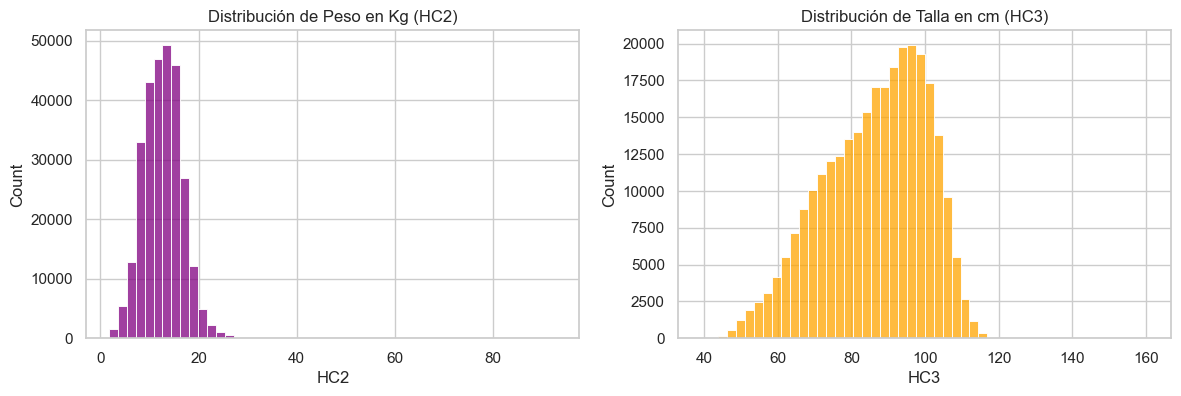

Método de medición (HC15):
HC15
De pie      177405
Acostado    108802
NaN           7902
Name: count, dtype: int64


In [11]:
# 1. Sexo del Niño (HC27)
print("Distribución por Sexo (HC27):")
print(df_rech6['HC27'].value_counts(normalize=True).round(3) * 100)

# 2. Distribución de Peso (HC2) y Talla (HC3) crudos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_rech6['HC2'].dropna(), bins=50, ax=axes[0], color='purple')
axes[0].set_title('Distribución de Peso en Kg (HC2)')
sns.histplot(df_rech6['HC3'].dropna(), bins=50, ax=axes[1], color='orange')
axes[1].set_title('Distribución de Talla en cm (HC3)')
plt.show()

# 3. Cómo fueron medidos (HC15: Acostado vs De pie)
print("Método de medición (HC15):")
print(df_rech6['HC15'].value_counts(dropna=False))

## 9. Conclusiones Biométricas Secundarias

*   **Demografía Equilibrada ()**: Muestra perfectamente balanceada (51% niños, 49% niñas), libre de sesgos de género.
*   **Biometría Cruda Validada ( y )**: Los pesos (3-25 kg) y tallas (50-115 cm) tienen distribuciones normales y lógicas. La regla divisoria () y la limpieza de valores atípicos () funcionaron correctamente.
*   **Método de Medición ()**: La proporción de niños medidos 'De pie' vs 'Acostado' explica estructuralmente el salto anómalo observado en la curva de edad a los 24 meses. Variable esencial para el modelo.


## 10. Justificación de Variables Excluidas del Análisis Visual

El archivo parquet cuenta con un total de 38 variables. Hemos auditado visualmente las 9 más críticas (Target OMS, Anemia, Peso, Talla, Edad, Sexo, Nulos, Posicion). Las 29 variables restantes se conservan en esta etapa intermedia (Interim/Silver) por reglas estrictas de Arquitectura de Datos, pero no se graficaron por las siguientes razones:

*   **Llaves Maestras y de Control (10 variables)**: `HHID`, `HC0`, `year`, `HC51`, `HC60`, etc. Son IDs alfanuméricos puros y números de línea de los padres. Son vitales para cruzar módulos (Joins), pero imposibles de graficar.
*   **Métricas de Tiempo y Fechas (8 variables)**: `HC16`, `HC19`, `HC30`, `HC31`, `HC32`, `HC33`, etc. Registran el día/mes/año exacto de la entrevista y nacimiento. Clínicamente, la variable Edad en meses (`HC1`) que ya analizamos resume matemáticamente toda esta maraña de fechas.
*   **Z-scores Obsoletos NCHS (11 variables)**: `HC4` a `HC12`. Son percentiles y cálculos de desnutrición basados en el antiguo estándar de EE.UU. (NCHS/CDC 1977). Actualmente la comunidad internacional usa el estándar OMS 2006 (`HC70` a `HC73`). Se conservan en el parquet temporalmente como "copia de seguridad" científica por si toca auditar algún error de cálculo del INEI.
*   **Métricas de Control de Sangre**: `HC53` y `HC55` son simples controles de si la madre aceptó o si el test se leyó bien. `HC56` es la hemoglobina cruda, pero su verdadera interpretación clínica y de riesgo ya está encapsulada en la variable final `HC57` (Nivel de Anemia ordinal) que sí analizamos a fondo.

**Nota para la Fase 4 (Feature Selection)**: Durante la creación del Dataset Final de Entrenamiento (Processed/Gold), estas 29 variables serán eliminadas permanentemente, ya que introducirlas a un modelo de Machine Learning generaría ruido o "Fuga de Datos" (Data Leakage).
